<a href="https://colab.research.google.com/github/AjanyaVinayan/ML-LAB-2547205/blob/lab---6/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

In [ ]:
import pandas as pd

# Define column names based on the dataset description
column_names = [
    'ID',
    'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Load the dataset
df = pd.read_csv('/content/wdbc.data', names=column_names)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

## 1. Exploratory Data Analysis and Preprocessing

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Encode the 'Diagnosis' column (M=1, B=0)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Drop the 'ID' column
df = df.drop('ID', axis=1)

# Display the class distribution of the 'Diagnosis' column
print("\nDistribution of Diagnosis (M=1, B=0):")
print(df['Diagnosis'].value_counts())

# Display the first few rows of the preprocessed DataFrame
print("\nFirst 5 rows of the preprocessed dataset:")
display(df.head())

Missing values in each column:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Distribution of Diagnosis (

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 1.2. Split Dataset into Training and Testing Sets & Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## 2. Model Implementation and Training

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

print("Logistic Regression model trained and predictions made.")

Logistic Regression model trained and predictions made.


### 2.2. Train a K Nearest Neighbors (KNN) Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5) # Using default n_neighbors=5
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

print("K Nearest Neighbors (KNN) model trained and predictions made.")

K Nearest Neighbors (KNN) model trained and predictions made.


## 3. Model Evaluation and Comparison


--- Logistic Regression Model Evaluation ---
Accuracy: 0.9649
Precision: 0.9750
Recall: 0.9286
F1 Score: 0.9512
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,71,1
Actual 1,3,39


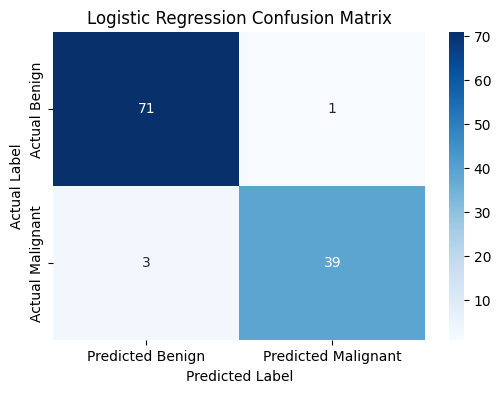


--- K Nearest Neighbors (KNN) Model Evaluation ---
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,71,1
Actual 1,4,38


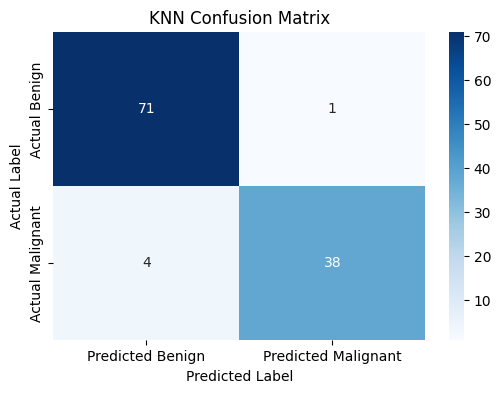


--- Model Performance Comparison ---


,Metric,Logistic Regression,KNN
0,Accuracy,0.964912,0.956140
1,Precision,0.975000,0.974359
2,Recall,0.928571,0.904762
3,F1 Score,0.951220,0.938272


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate Logistic Regression Model ---
print("\n--- Logistic Regression Model Evaluation ---")

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_lr:.4f}")

# Precision
precision_lr = precision_score(y_test, y_pred_log_reg)
print(f"Precision: {precision_lr:.4f}")

# Recall
recall_lr = recall_score(y_test, y_pred_log_reg)
print(f"Recall: {recall_lr:.4f}")

# F1 Score
f1_lr = f1_score(y_test, y_pred_log_reg)
print(f"F1 Score: {f1_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix:")
display(pd.DataFrame(cm_lr, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Evaluate K Nearest Neighbors (KNN) Model ---
print("\n--- K Nearest Neighbors (KNN) Model Evaluation ---")

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.4f}")

# Precision
precision_knn = precision_score(y_test, y_pred_knn)
print(f"Precision: {precision_knn:.4f}")

# Recall
recall_knn = recall_score(y_test, y_pred_knn)
print(f"Recall: {recall_knn:.4f}")

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn)
print(f"F1 Score: {f1_knn:.4f}")

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:")
display(pd.DataFrame(cm_knn, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# Store metrics for comparison
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr],
    'KNN': [accuracy_knn, precision_knn, recall_knn, f1_knn]
}

comparison_df = pd.DataFrame(metrics_data)

print("\n--- Model Performance Comparison ---")
display(comparison_df)


### Conclusion: Better Classifier

Logistic Regression is slightly better than the other model.

Both models have good accuracy and precision, but Logistic Regression has **higher Recall and F1 Score**.

In breast cancer prediction, **Recall is very important** because it helps identify more actual cancer cases and reduces the chance of missing a patient with cancer.

Therefore, **Logistic Regression is the better classifier for this dataset**.
